In [ ]:
                                    Logistic Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [ ]:
1. Data Exploration:

In [2]:
# a.Load the dataset and perform exploratory data analysis (EDA).

df= pd.read_csv('diabetes.csv')

In [3]:
#Getting top5 data
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# b. Examine the features, their types, and summary statistics.
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [5]:
# Datatypes of the columns/features
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [6]:
# Statistics of dataset

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
#c. Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.

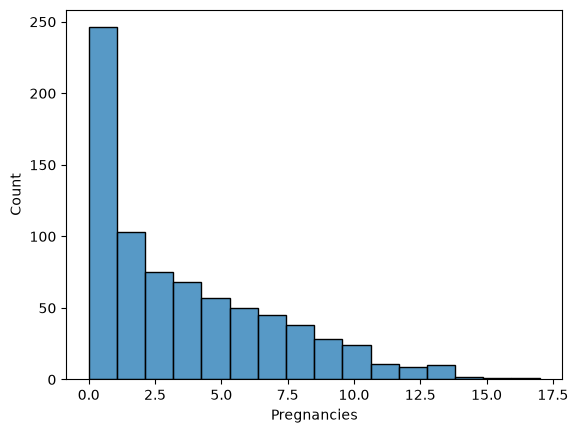

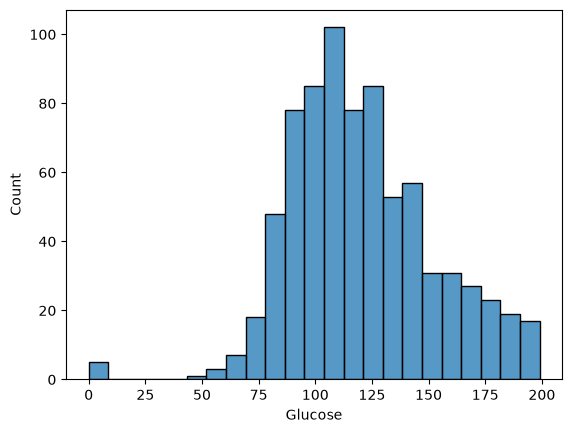

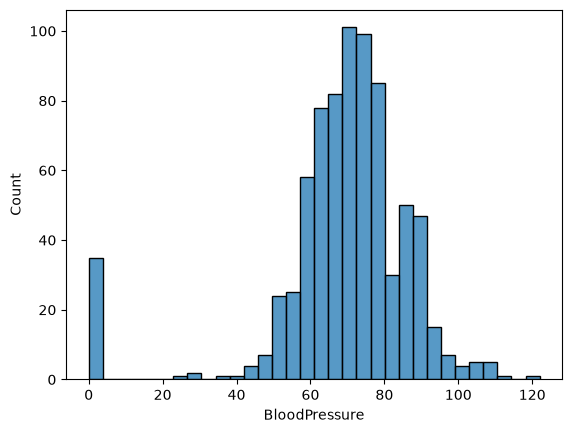

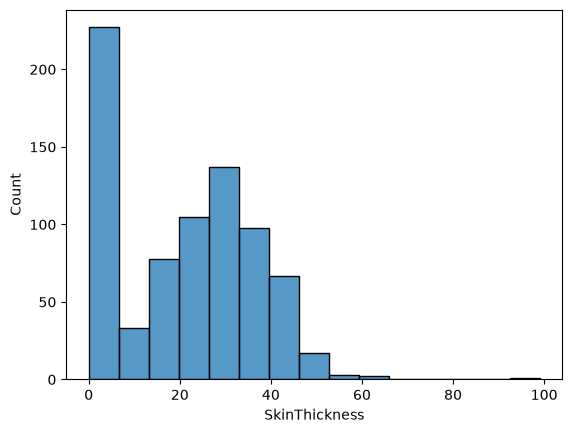

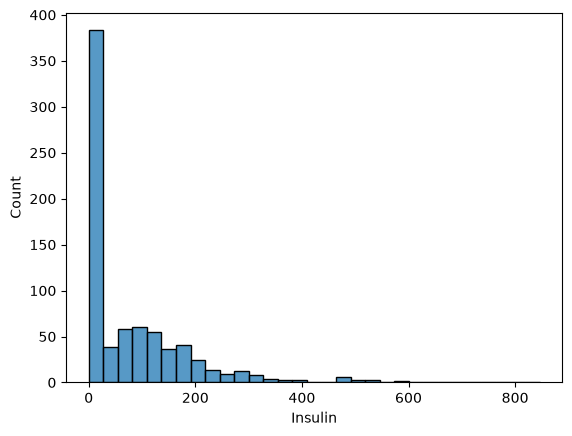

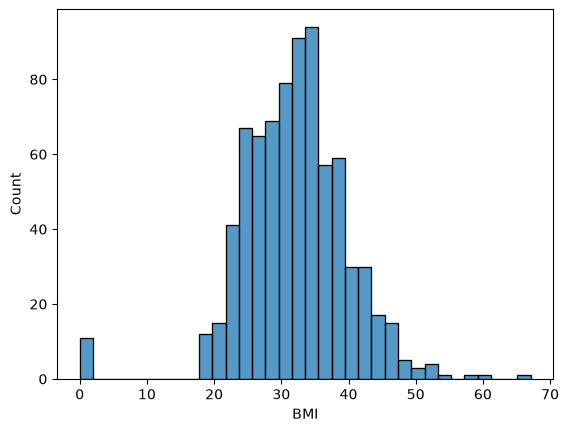

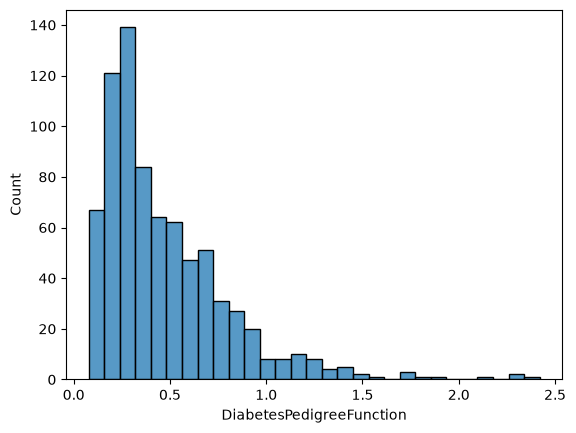

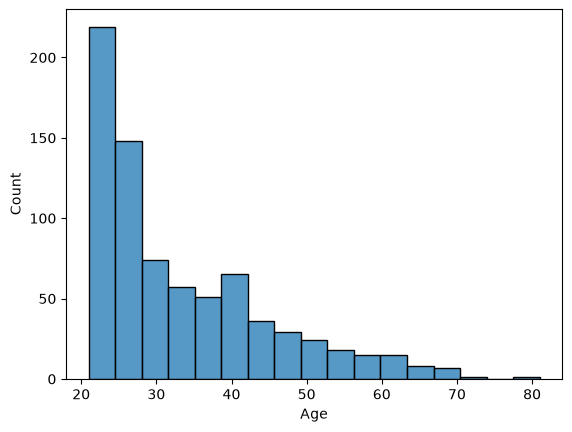

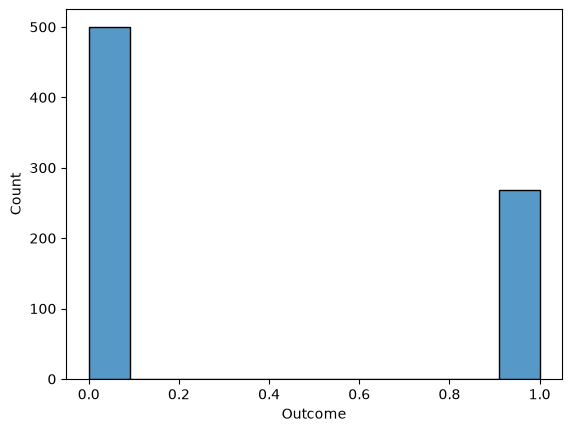

In [7]:
#Histogram
for i in df.select_dtypes(include=['int64','float64']).columns:
    sns.histplot(df[i])
    plt.show()

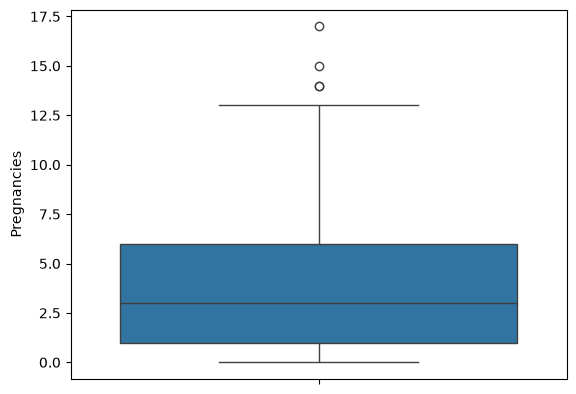

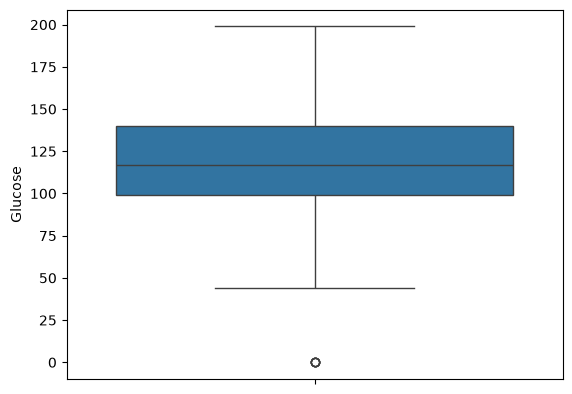

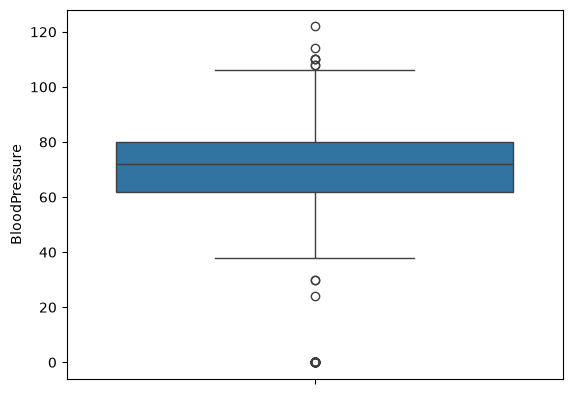

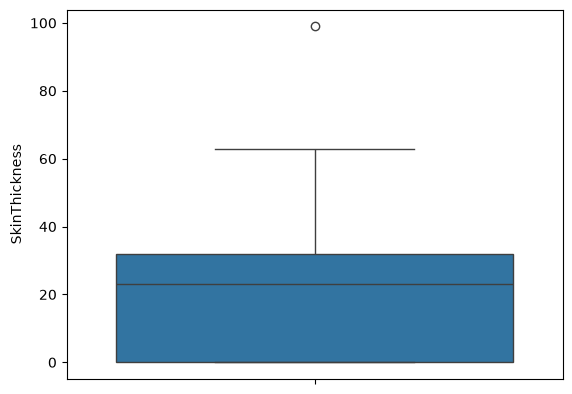

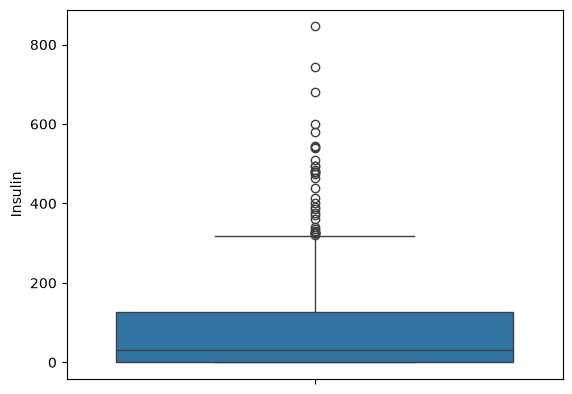

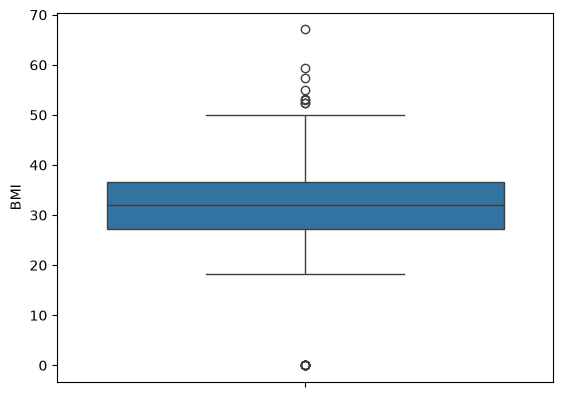

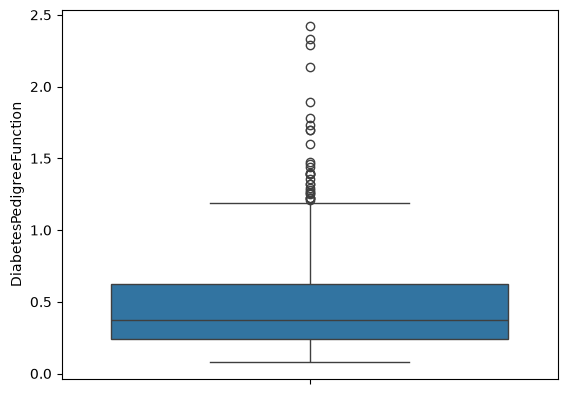

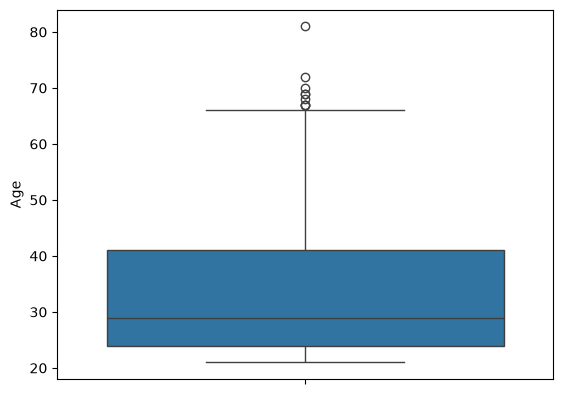

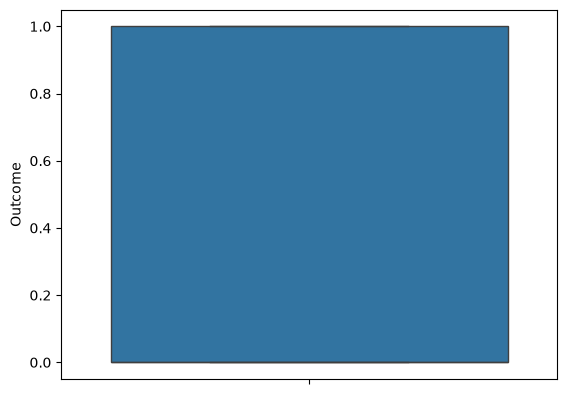

In [8]:
#Boxplot
for i in df.select_dtypes(include=['int64','float64']).columns:
    sns.boxplot(df[i])
    plt.show()

In [ ]:
Analyze any patterns or correlations observed in the data.

by seeing the raw data we cannot tell what is inside and the mathematical calculations in the dataset. By performing the EDA operations we can tell all
the mathematical calculations.
    
Histogram: The histogram will belp us to know the skewness of the data. Wheather the column/feature data is leftskew or rightskew.
Boxplot: The boxplot is used only for the numerical data (int and float) by seeing the graphs we can tell wheather there are outliers or not.
    

In [ ]:
2. Data Preprocessing:

In [ ]:
a. Handle missing values (e.g., imputation).

In [9]:
#Checking the null values for each column
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [10]:
#Checking the null values sum
df.isnull().sum().sum()

np.int64(0)

In [11]:
#Checking the duplicate values
df.duplicated().sum()

np.int64(0)

In [12]:
#Checking the q1,q3,iqr,lower and upper bound values
for i in df.select_dtypes(include=['int64','float64']).columns:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    iqr=q3-q1
    lower_bound= q1 - 1.5*iqr
    upper_bound= q3 + 1.5*iqr
    print()
    print(i)
    print("Q1 value is: ",q1)
    print("Q3 value is: ",q3)
    print("IQR value is: ",iqr)
    print("Lower Bound value is: ",lower_bound)
    print("Upper Bound value is: ",upper_bound)


Pregnancies
Q1 value is:  1.0
Q3 value is:  6.0
IQR value is:  5.0
Lower Bound value is:  -6.5
Upper Bound value is:  13.5

Glucose
Q1 value is:  99.0
Q3 value is:  140.25
IQR value is:  41.25
Lower Bound value is:  37.125
Upper Bound value is:  202.125

BloodPressure
Q1 value is:  62.0
Q3 value is:  80.0
IQR value is:  18.0
Lower Bound value is:  35.0
Upper Bound value is:  107.0

SkinThickness
Q1 value is:  0.0
Q3 value is:  32.0
IQR value is:  32.0
Lower Bound value is:  -48.0
Upper Bound value is:  80.0

Insulin
Q1 value is:  0.0
Q3 value is:  127.25
IQR value is:  127.25
Lower Bound value is:  -190.875
Upper Bound value is:  318.125

BMI
Q1 value is:  27.3
Q3 value is:  36.6
IQR value is:  9.3
Lower Bound value is:  13.35
Upper Bound value is:  50.550000000000004

DiabetesPedigreeFunction
Q1 value is:  0.24375
Q3 value is:  0.62625
IQR value is:  0.38249999999999995
Lower Bound value is:  -0.32999999999999996
Upper Bound value is:  1.2

Age
Q1 value is:  24.0
Q3 value is:  41.0
I

In [13]:
#Outlier capping
for i in df.select_dtypes(include=['int64','float64']).columns:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    iqr=q3-q1
    lower_bound= q1-1.5*iqr
    upper_bound= q3+1.5*iqr
    df[i]=df[i].clip(lower_bound,upper_bound)

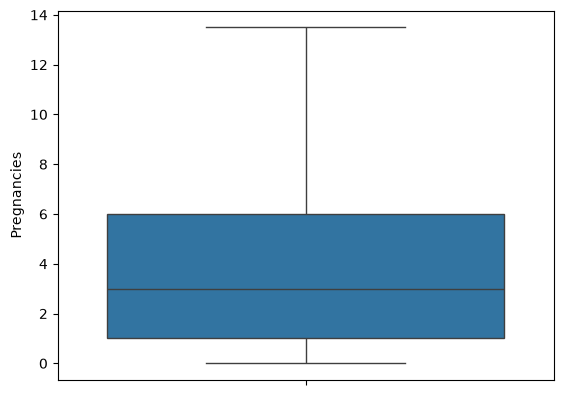

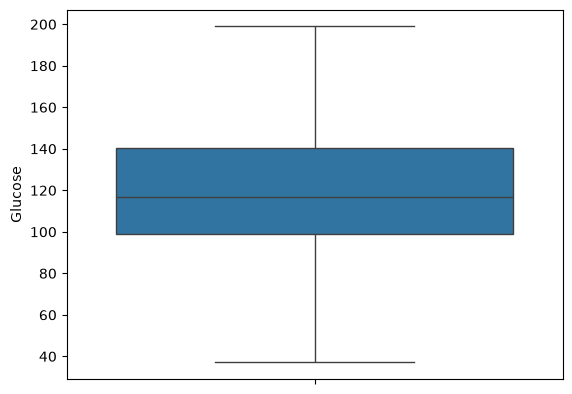

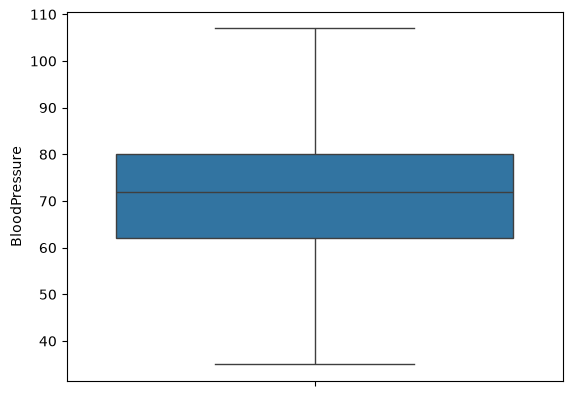

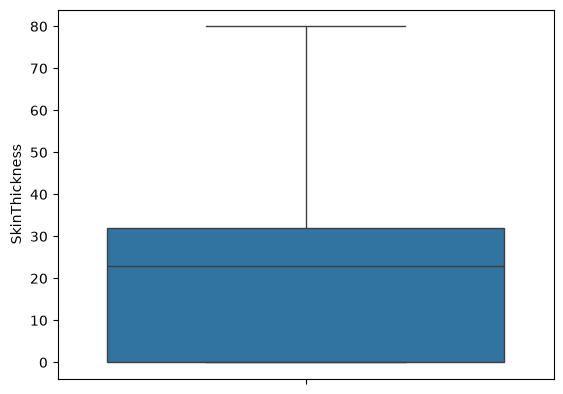

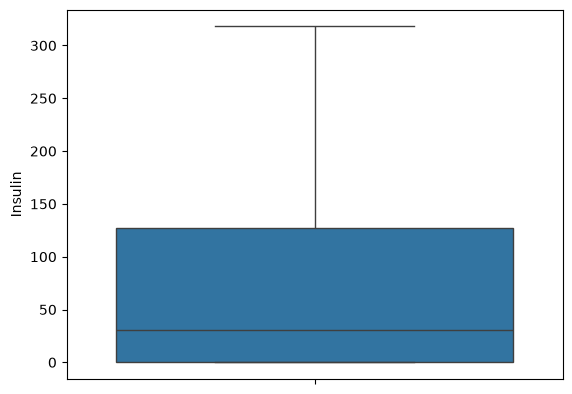

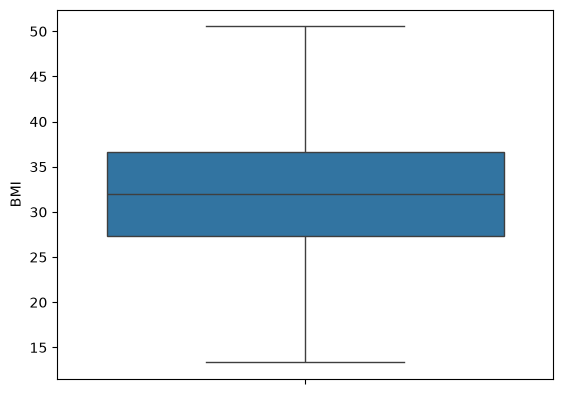

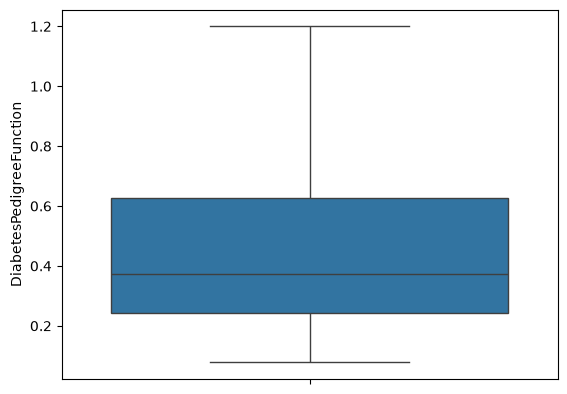

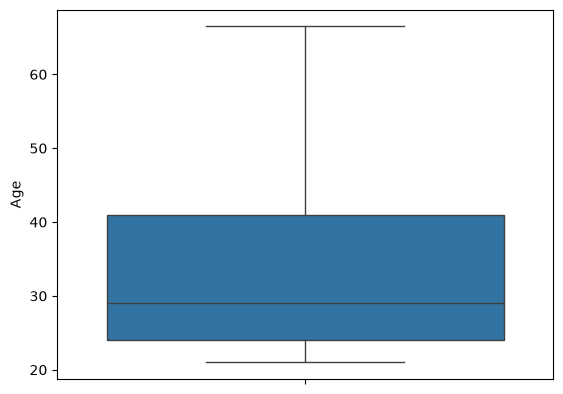

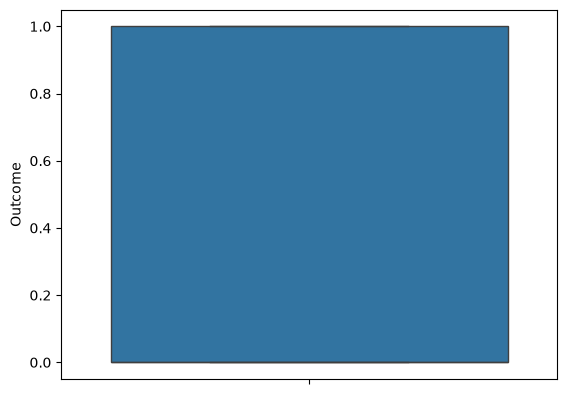

In [14]:
#Checking wheather the values are capped or not
for i in df.select_dtypes(include=['int64','float64']).columns:
    sns.boxplot(df[i])
    plt.show()

In [ ]:
b. Encode categorical variables.

In [15]:
#Checking for the categorical columns
df.select_dtypes(include=['object']).columns

Index([], dtype='str')

In [16]:
#Checking for the numerical columns
df.select_dtypes(include=['int64','float64']).columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [18]:
 Encoding techniques are used only for the categorical data.
 There are no categorical data in the dataset.

In [ ]:
3. Model Building:

In [ ]:
a. Build a logistic regression model using appropriate libraries (e.g., scikit-learn).
b. Train the model using the training data.

In [19]:
#dividing data into features and target
features=df.drop(columns=['Outcome'])
target=df['Outcome']

In [20]:
# b. Train the model using the training data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(features,target,test_size=0.2,random_state=90)

In [21]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [22]:
#Training prediction
pred_train=lr.predict(x_train)
pred_train

array([0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,

In [23]:
#Testing prediction
pred_test=lr.predict(x_test)
pred_test

array([0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0])

In [ ]:
4. Model Evaluation:

In [ ]:
a. Evaluate the performance of the model on the testing data using accuracy, precision, recall, F1-score, and ROC-AUC score.

In [24]:
#Accuracy

from sklearn.metrics import accuracy_score
print("Train Accuracy is: ",accuracy_score(y_train,pred_train))
print("Test Accuracy is: ",accuracy_score(y_test,pred_test))

Train Accuracy is:  0.7817589576547231
Test Accuracy is:  0.7792207792207793


In [25]:
#Classification report for training data
from sklearn.metrics import classification_report
print("Training Report: ",classification_report(y_train,pred_train))

Training Report:                precision    recall  f1-score   support

           0       0.80      0.89      0.84       397
           1       0.74      0.59      0.65       217

    accuracy                           0.78       614
   macro avg       0.77      0.74      0.75       614
weighted avg       0.78      0.78      0.77       614



In [51]:
#Classification Report for testing data
from sklearn.metrics import classification_report
print("Testing Report: ",classification_report(y_test,pred_test))

Testing Report:                precision    recall  f1-score   support

           0       0.81      0.87      0.84       103
           1       0.70      0.59      0.64        51

    accuracy                           0.78       154
   macro avg       0.75      0.73      0.74       154
weighted avg       0.77      0.78      0.77       154



In [26]:
# ROC-AUC score. Training
from sklearn.metrics import roc_auc_score
print("Training ROC_AUC_SCORE: ",roc_auc_score(y_train,pred_train))

Training ROC_AUC_SCORE:  0.7372111109821357


In [27]:
# ROC-AUC score. Testing
from sklearn.metrics import roc_auc_score
print("Testing ROC_AUC_SCORE: ",roc_auc_score(y_test,pred_test))

Testing ROC_AUC_SCORE:  0.7310108509423188


In [28]:
#AUC ROC CURVE
sigmoid= lr.predict_proba(x_test)[:,1]   #Getting the sigmoid values
sigmoid

array([0.47516673, 0.27512665, 0.51407499, 0.03757065, 0.80853117,
       0.0440764 , 0.28161872, 0.17493463, 0.48447123, 0.7348167 ,
       0.07925823, 0.59366382, 0.17216453, 0.12423964, 0.06123028,
       0.51392793, 0.09551371, 0.3541594 , 0.08501306, 0.75726339,
       0.08625486, 0.16466655, 0.63322466, 0.36025232, 0.29559635,
       0.02633525, 0.01981421, 0.27414757, 0.56025171, 0.03080295,
       0.5309598 , 0.21190122, 0.34108989, 0.46588875, 0.75674882,
       0.45347512, 0.76667733, 0.14553822, 0.02983951, 0.19502655,
       0.87137085, 0.16687682, 0.23161788, 0.65422746, 0.94025907,
       0.04298639, 0.26699597, 0.11698099, 0.04297057, 0.94066253,
       0.38254031, 0.2725945 , 0.5014108 , 0.75405169, 0.3257944 ,
       0.06254949, 0.07920511, 0.23778966, 0.6848846 , 0.87499237,
       0.53897873, 0.08624444, 0.18748236, 0.42975685, 0.1187659 ,
       0.08499462, 0.45285478, 0.78995665, 0.08010556, 0.31528066,
       0.41732025, 0.11259529, 0.79263155, 0.03197266, 0.83797

In [29]:
from sklearn.metrics import roc_auc_score,roc_curve
auc_score= roc_auc_score(y_test,sigmoid)
auc_score

0.8416143156291642

In [30]:
roc_curve(y_test,sigmoid)    
#Here we are getting the FPR,TPR,THRESHOLD

(array([0.        , 0.        , 0.        , 0.00970874, 0.00970874,
        0.01941748, 0.01941748, 0.03883495, 0.03883495, 0.04854369,
        0.04854369, 0.05825243, 0.05825243, 0.09708738, 0.09708738,
        0.16504854, 0.16504854, 0.17475728, 0.17475728, 0.19417476,
        0.19417476, 0.2038835 , 0.2038835 , 0.23300971, 0.23300971,
        0.25242718, 0.25242718, 0.27184466, 0.27184466, 0.30097087,
        0.30097087, 0.31067961, 0.31067961, 0.33009709, 0.33009709,
        0.33980583, 0.33980583, 0.3592233 , 0.3592233 , 0.36893204,
        0.36893204, 0.37864078, 0.37864078, 0.40776699, 0.40776699,
        0.4368932 , 0.4368932 , 0.44660194, 0.44660194, 0.49514563,
        0.49514563, 0.54368932, 0.54368932, 1.        ]),
 array([0.        , 0.01960784, 0.07843137, 0.07843137, 0.11764706,
        0.11764706, 0.35294118, 0.35294118, 0.39215686, 0.39215686,
        0.47058824, 0.47058824, 0.49019608, 0.49019608, 0.58823529,
        0.58823529, 0.60784314, 0.60784314, 0.62745098, 0.

In [31]:
#Getting the FPR values
roc_curve(y_test,sigmoid)[0]

array([0.        , 0.        , 0.        , 0.00970874, 0.00970874,
       0.01941748, 0.01941748, 0.03883495, 0.03883495, 0.04854369,
       0.04854369, 0.05825243, 0.05825243, 0.09708738, 0.09708738,
       0.16504854, 0.16504854, 0.17475728, 0.17475728, 0.19417476,
       0.19417476, 0.2038835 , 0.2038835 , 0.23300971, 0.23300971,
       0.25242718, 0.25242718, 0.27184466, 0.27184466, 0.30097087,
       0.30097087, 0.31067961, 0.31067961, 0.33009709, 0.33009709,
       0.33980583, 0.33980583, 0.3592233 , 0.3592233 , 0.36893204,
       0.36893204, 0.37864078, 0.37864078, 0.40776699, 0.40776699,
       0.4368932 , 0.4368932 , 0.44660194, 0.44660194, 0.49514563,
       0.49514563, 0.54368932, 0.54368932, 1.        ])

In [32]:
#Getting the TPR values
roc_curve(y_test,sigmoid)[1]

array([0.        , 0.01960784, 0.07843137, 0.07843137, 0.11764706,
       0.11764706, 0.35294118, 0.35294118, 0.39215686, 0.39215686,
       0.47058824, 0.47058824, 0.49019608, 0.49019608, 0.58823529,
       0.58823529, 0.60784314, 0.60784314, 0.62745098, 0.62745098,
       0.64705882, 0.64705882, 0.66666667, 0.66666667, 0.68627451,
       0.68627451, 0.7254902 , 0.7254902 , 0.74509804, 0.74509804,
       0.76470588, 0.76470588, 0.78431373, 0.78431373, 0.80392157,
       0.80392157, 0.82352941, 0.82352941, 0.84313725, 0.84313725,
       0.8627451 , 0.8627451 , 0.88235294, 0.88235294, 0.90196078,
       0.90196078, 0.92156863, 0.92156863, 0.94117647, 0.94117647,
       0.96078431, 0.96078431, 1.        , 1.        ])

In [33]:
#Getting the Threshold values
roc_curve(y_test,sigmoid)[2]

array([       inf, 0.95614185, 0.91992021, 0.90540996, 0.87499237,
       0.87137085, 0.75405169, 0.72178477, 0.6848846 , 0.66891988,
       0.65422746, 0.634332  , 0.63322466, 0.58076349, 0.5309598 ,
       0.45347512, 0.45285478, 0.44419987, 0.44240696, 0.42975685,
       0.42732917, 0.42548963, 0.42501206, 0.40290857, 0.39902609,
       0.38254031, 0.36025232, 0.34108989, 0.33412479, 0.31528066,
       0.31432413, 0.30825006, 0.29559635, 0.28748892, 0.28231715,
       0.28161872, 0.27975976, 0.27509609, 0.27414757, 0.2725945 ,
       0.2698373 , 0.26699597, 0.250315  , 0.23161788, 0.21190122,
       0.19764959, 0.19502655, 0.18748236, 0.18079453, 0.16642029,
       0.16466655, 0.14578615, 0.14018999, 0.00986978])

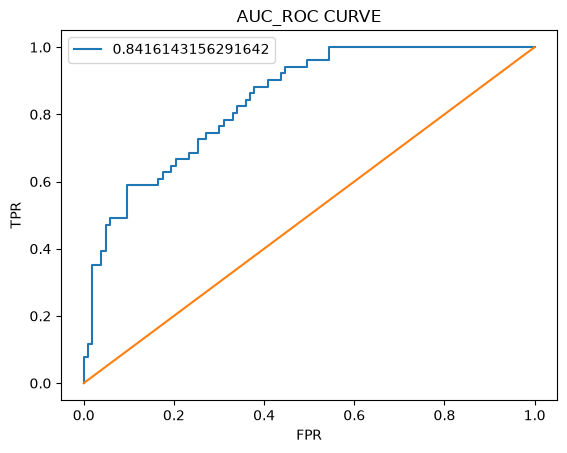

In [34]:
# Visualize the ROC curve.
fpr,tpr,thr= roc_curve(y_test,sigmoid)
plt.plot(fpr,tpr,label= f'{auc_score}')
plt.plot([0,1])
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("AUC_ROC CURVE")
plt.legend()
plt.show()

In [ ]:
5. Interpretation:
a. Interpret the coefficients of the logistic regression model

In [35]:
#Intercept value
lr.intercept_

array([-8.82481052])

In [36]:
#Coefficient values
lr.coef_

array([[ 1.41752961e-01,  3.64764420e-02, -1.76970408e-02,
        -1.61228812e-04, -2.38516759e-03,  1.09618556e-01,
         1.03024367e+00,  1.29360510e-02]])

In [ ]:
b. Discuss the significance of features in predicting the target variable (survival probability in this case).


The positive coefficients show that these features increase the chance of diabetes, while negative coefficients decrease it. 
Glucose, BMI and DiabetesPedigreeFunction have a positive effect. BloodPressure, SkinThickness and Insulin have a negative effect. 
SkinThickness and Insulin have very small coefficients, so their effect is comparatively low.

In [37]:
import joblib
joblib.dump(lr,'model.pkl')

['model.pkl']

In [ ]:
1. What is the difference between precision and recall?

The precision and recall are the evaluation metrics of the Classification problem

precison :  TP/TP+FP       
recall : TP/TP+FN

TP:True-Positive (Actual is positive and Predicted also positive)
FP(also called as type 1 error):False-Positive (Actual is negative and predicted is positive)
FN (also called as type 2 error):False-Negative (Actual is positive and predicted is Negative)


In [ ]:
2. What is cross-validation, and why is it important in binary classification?

The cross-validation is the technique where it will going to reduce the over fitting condition
*When the data is only present in the testing phase but not in the training phase then the model will not learn about only the data that is present
in testing but not in training this leads to the over fitting condition
By using the Cross-Validation technique we can over come this problem
Types of cross-validation techniques:
1.Hold out
2. Shuffle Split
3. Startified shuffle split
4. K-Fold